In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/long_format_synth_12M_4Q.csv")


df["Timestamp"] = pd.to_numeric(df["Timestamp"], errors="coerce")
df["Variable"] = df["Variable"].astype(str)
df["Frequency"] = df["Frequency"].astype(str)


df_wide_all = df.pivot(index="Timestamp", columns="Variable", values="Value").sort_index()
df_wide_M   = df[df["Frequency"] == "M"].pivot(index="Timestamp", columns="Variable", values="Value").sort_index()
df_wide_Q   = df[df["Frequency"] == "Q"].pivot(index="Timestamp", columns="Variable", values="Value").sort_index()


display(df.head(), df_wide_all.head())

,Timestamp,Variable,Value,Frequency
0,0,X1,1.570315,M
1,0,X2,-0.825168,M
2,0,X3,3.209472,M
3,0,X4,-0.306842,M
4,0,X5,0.051134,M


Variable,X1,X10,X11,X12,X2,X3,X4,X5,X6,X7,X8,X9,Y1,Y2,Y3,Y4
Timestamp,,,,,,,,,,,,,,,,
0,1.570315,-0.326859,0.549041,1.661331,-0.825168,3.209472,-0.306842,0.051134,2.187174,-0.422508,-0.642567,3.670811,NaN,NaN,NaN,NaN
1,0.459745,-1.269613,-0.393462,-1.883509,1.926618,1.797307,-2.669624,0.540778,1.712844,-2.059279,0.554497,2.226978,NaN,NaN,NaN,NaN
2,0.800550,0.075654,-1.011121,0.269032,1.770591,1.876380,-1.971971,-2.223900,1.868655,-1.022512,1.934777,2.098347,-0.543372,-0.947499,0.354505,0.776013
3,-1.752836,-0.800262,-1.543923,-1.178016,-2.533419,0.854616,-2.066345,-1.002549,2.891717,-3.054437,-2.355056,1.656667,NaN,NaN,NaN,NaN
4,-2.742096,-1.732025,1.483514,-1.624737,-0.464333,3.276598,-3.239998,0.117309,2.795187,-1.097522,-0.973211,0.921634,NaN,NaN,NaN,NaN


In [8]:
def _zscore(a: pd.DataFrame) -> pd.DataFrame:
    return (a - a.mean()) / (a.std(ddof=0) + 1e-12)

def get_wide(freq: str) -> pd.DataFrame:
    if freq == "Monthly (M)":
        return df_wide_M
    elif freq == "Quarterly (Q)":
        return df_wide_Q
    else:
        return df_wide_all

def plot_series(variables, freq="Monthly (M)", zscore=False):
    """Plot selected variables for a given frequency."""
    wide = get_wide(freq)
    vars_ok = [v for v in variables if v in wide.columns]
    if not vars_ok:
        print("No selected variables found in this frequency selection.")
        return

    data = wide[vars_ok].copy()
    if zscore:
        data = _zscore(data)

    plt.figure(figsize=(10, 4 + 0.3 * len(vars_ok)))
    data.plot(ax=plt.gca())
    plt.title(f"Selected variables ({freq})" + (" — z-scored" if zscore else ""))
    plt.xlabel("Timestamp")
    plt.ylabel("Value")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def corr_matrix(freq="Monthly (M)", min_periods=10):
    """Compute correlation matrix for a given frequency."""
    wide = get_wide(freq)
    return wide.corr(min_periods=min_periods)

def plot_corr_heatmap(freq="Monthly (M)", min_periods=10, cmap="coolwarm", annotate=True):
    """Plot correlation heatmap for selected frequency with optional numeric annotations."""
    C = corr_matrix(freq, min_periods=min_periods)
    plt.figure(figsize=(8, 6))
    im = plt.imshow(C.values, aspect="auto", interpolation="nearest", cmap=cmap, vmin=-1, vmax=1)
    plt.colorbar(im, fraction=0.046, pad=0.04)

    plt.xticks(ticks=np.arange(C.shape[1]), labels=C.columns, rotation=90)
    plt.yticks(ticks=np.arange(C.shape[0]), labels=C.index)
    plt.title(f"Correlation matrix — {freq} (min_periods={min_periods})")

    # Annotate correlation coefficients
    if annotate:
        for i in range(C.shape[0]):
            for j in range(C.shape[1]):
                value = C.values[i, j]
                plt.text(
                    j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color="white" if abs(value) > 0.5 else "black",
                    fontsize=8
                )

    plt.tight_layout()
    plt.show()
    return C


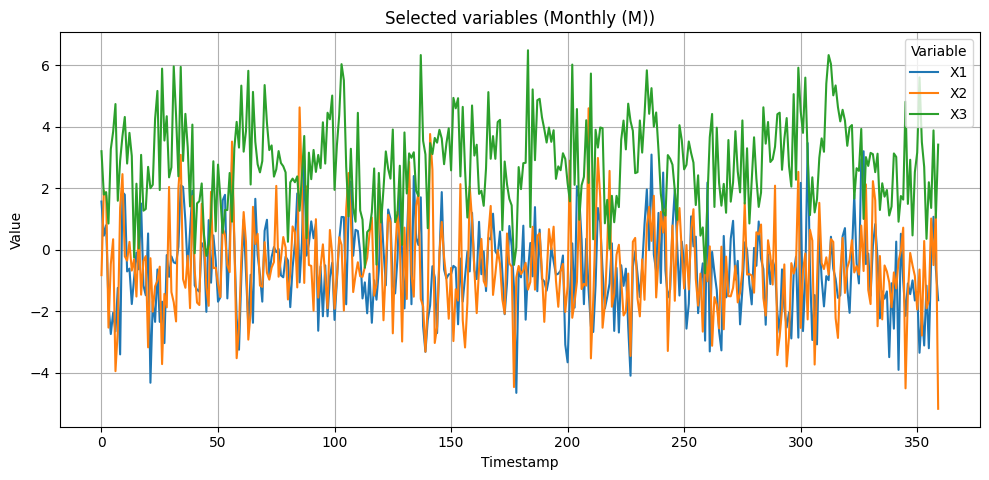

In [10]:
# Plot a few variables
plot_series(["X1", "X2", "X3"], freq="Monthly (M)", zscore=False)

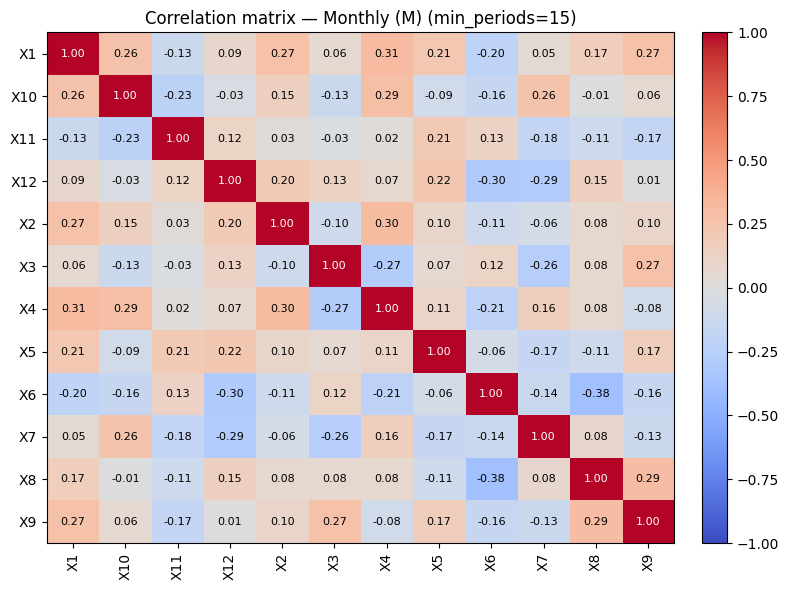

Variable,X1,X10,X11,X12,X2,X3,X4,X5,X6,X7,X8,X9
Variable,,,,,,,,,,,,
X1,1.000000,0.258313,-0.127653,0.092492,0.271689,0.064977,0.312367,0.211981,-0.204461,0.051294,0.170207,0.266588
X10,0.258313,1.000000,-0.225904,-0.034938,0.151007,-0.127380,0.286548,-0.092851,-0.156143,0.256965,-0.011676,0.063203
X11,-0.127653,-0.225904,1.000000,0.118888,0.029870,-0.027129,0.018013,0.208928,0.128594,-0.179208,-0.110347,-0.172580
X12,0.092492,-0.034938,0.118888,1.000000,0.201433,0.130644,0.073585,0.223898,-0.300089,-0.287726,0.153222,0.005717
X2,0.271689,0.151007,0.029870,0.201433,1.000000,-0.102317,0.299870,0.095747,-0.108777,-0.062917,0.076543,0.101932
X3,0.064977,-0.127380,-0.027129,0.130644,-0.102317,1.000000,-0.274718,0.067950,0.118926,-0.264182,0.077093,0.272666
X4,0.312367,0.286548,0.018013,0.073585,0.299870,-0.274718,1.000000,0.114897,-0.211271,0.162129,0.077785,-0.079479
X5,0.211981,-0.092851,0.208928,0.223898,0.095747,0.067950,0.114897,1.000000,-0.062990,-0.168471,-0.105810,0.172209
X6,-0.204461,-0.156143,0.128594,-0.300089,-0.108777,0.118926,-0.211271,-0.062990,1.000000,-0.140362,-0.381356,-0.155995


In [11]:
# Plot correlation matrix
plot_corr_heatmap(freq="Monthly (M)", min_periods=15)

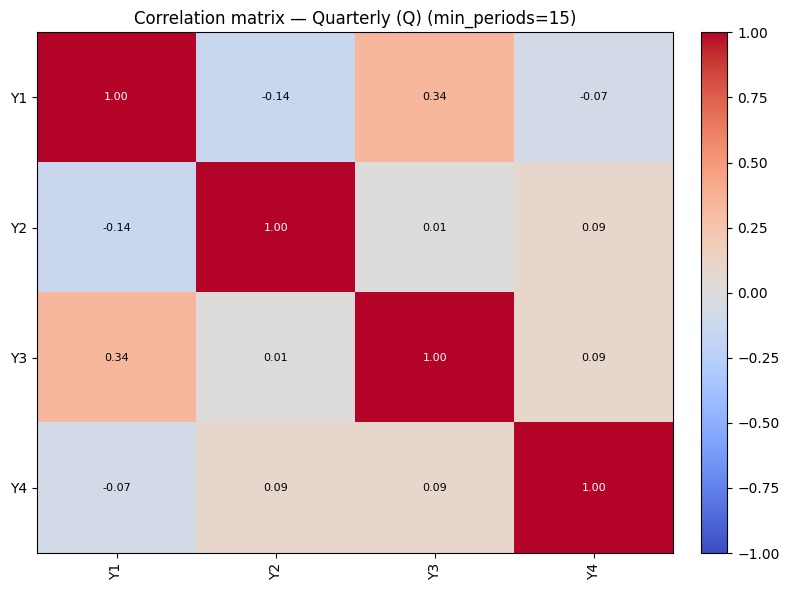

Variable,Y1,Y2,Y3,Y4
Variable,,,,
Y1,1.000000,-0.136194,0.335254,-0.074111
Y2,-0.136194,1.000000,0.006334,0.091293
Y3,0.335254,0.006334,1.000000,0.091546
Y4,-0.074111,0.091293,0.091546,1.000000


In [12]:
# Plot correlation matrix
plot_corr_heatmap(freq="Quarterly (Q)", min_periods=15)